#### Trained in Kaggle

In [1]:
!pip install polars

In [2]:
import polars as pl
import numpy as np

import matplotlib.pyplot as plt
import yaml
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

In [3]:
# data utils

import os
import pickle
import polars as pl
import numpy as np
from torch.utils.data import Dataset
import torch

def read_pkl(path: str) -> dict:
    with open(path, 'rb') as fo:
        d = pickle.load(fo, encoding='bytes')
    return d 

def make_df(path: str, metadata: dict) -> pl.DataFrame:
    d = read_pkl(path)
    img_data = [np.dstack([img[i: i + 1024].reshape((32, 32)) for i in range(0, len(img), 1024)]).astype(np.uint8) for img in d[b'data']]
    _data_dict = {
        "label": d[b'labels'],
        "label_names": [metadata[b'label_names'][l].decode("utf-8") for l in d[b'labels']]
    }
    _df = pl.DataFrame(_data_dict)
    _df = _df.with_columns(pl.Series("data", img_data, dtype=pl.Object))
    return _df


def make_df2(path: str, metadata: dict) -> pl.DataFrame:
    d = read_pkl(path)
    # _data_dict = {"data": val for i, val in enumerate(d[b'data'])}
    _data_dict ={}
    _data_dict["label"] = d[b'labels']
    _data_dict["data"] = d[b'data']
    _data_dict["label_names"] = [metadata[b'label_names'][l].decode("utf-8") for l in d[b'labels']]
    _df = pl.DataFrame(_data_dict)
    return _df

def read_data(path: str) -> tuple[pl.DataFrame]:
    meta = os.path.join(path, "batches.meta")
    train_pref = "data_batch_"
    test_pref = "test"
    
    files = os.listdir(path)
    
    metadata = read_pkl(meta)
    
    train_data = []
    test_data = []
    for file in files:
        if file.startswith(train_pref):
            train_data.append(make_df(os.path.join(path, file), metadata))
        elif file.startswith(test_pref):
            test_data.append(make_df(os.path.join(path, file), metadata))
    
    return pl.concat(train_data, how="vertical"), pl.concat(test_data, how="vertical")

def read_data_v2(path: str) -> tuple[pl.DataFrame]:
    meta = os.path.join(path, "batches.meta")
    train_pref = "data_batch_"
    test_pref = "test"
    
    files = os.listdir(path)
    
    metadata = read_pkl(meta)
    
    train_data = []
    test_data = []
    for file in files:
        if file.startswith(train_pref):
            train_data.append(make_df2(os.path.join(path, file), metadata))
        elif file.startswith(test_pref):
            test_data.append(make_df2(os.path.join(path, file), metadata))
    
    return pl.concat(train_data, how="vertical"), pl.concat(test_data, how="vertical")


class CIFARData(Dataset):
    def __init__(self, df: pl.DataFrame):
        super().__init__()
        self.df = df
    
    def __len__(self):
        return self.df.shape[0]
    
    def __getitem__(self, index):
        return {
            "data": torch.tensor(np.asarray(self.df[index]["data"].to_list()), dtype=torch.float32),
            "label": torch.tensor(np.asarray(self.df[index]["label"].to_list()), dtype=torch.long),
        }

def shift_data(val: list[int]):
    shift = 4
    size = 32
    
    new_data = []
    for i in range(0, len(val), size):
        new_data.extend((([0] * shift) + val[i : i + size])[:size])
    return new_data

In [4]:
# eval 

from typing import Literal
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

def evaluate(y_true, y_pred):
    print(classification_report(y_true, y_pred, digits=4))
    return confusion_matrix(y_true, y_pred)

def format_cm(cm, *, 
              class_names: list[str] | None = None, 
              normalize: bool = False,
              normalize_axis: Literal[0, 1] = 1) -> pd.DataFrame:
    if not class_names:
        class_names = [f"class-{i}" for i in range(len(cm))]
    
    cm_df = pd.DataFrame(cm,
                         index=[f"True: {c}" for c in class_names],
                         columns=[f"Pred: {c}" for c in class_names]
                         )
    if not normalize:
        return cm_df
    
    cm_normalized = cm_df.div(cm_df.sum(axis=normalize_axis), axis= 0 if normalize_axis == 1 else 1)
    cm_normalized = cm_normalized.round(4)
    return cm_normalized

In [5]:
# network

import torch
import torch.nn as nn
import torchvision.models as ftmodels

class ResNetFTv03(nn.Module):
    def __init__(self, n_classes: int = 10):
        super().__init__()
        
        self.base_model = ftmodels.resnet18(weights="DEFAULT")
        
        self.base_model.conv1 = nn.Conv2d(
            in_channels=3, out_channels=64, kernel_size=3, stride=1, padding=1
        )
        self.base_model.maxpool = nn.Identity()
        
        out_feature = self.base_model.fc.in_features
        self.base_model.fc = nn.Identity()
        
        self.head = nn.Sequential(
            nn.Linear(out_feature, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(),
            
            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(),
            
            nn.Linear(128, n_classes),
        )
        
        self.classifier = nn.Sequential(
            self.base_model,
            self.head
        )   
        
        for layer in self.head:
            if isinstance(layer, nn.Linear):
                nn.init.kaiming_uniform_(layer.weight)
                if layer.bias != None:
                    nn.init.zeros_(layer.bias)
        
    def forward(self, _input): # shape [batch, color, h, w]
        logit = self.classifier(_input)
        return logit

In [6]:
import os
PATH = "/kaggle/input/datasets/amallick0507/cifar10/cifar-10-batches-py"
comb_df, test_df = read_data_v2(PATH)

# with open("../configs/base_config.yaml", 'r') as f:
#     base_config = yaml.safe_load(f)

comb_df.shape, test_df.shape

meta = os.path.join(PATH, "batches.meta")

metadata = read_pkl(meta)
label_name = [l.decode("utf-8") for l in metadata[b'label_names']]

In [7]:
SEED = 15002
VAL_SPLIT = 0.2
GPU = 'cuda'
TRAIN_BATCH = 128
BATCH = 256

In [8]:
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [9]:

from sklearn.model_selection import train_test_split
X = comb_df["data"]; y = comb_df["label"]
X_test = test_df["data"]; y_test = test_df["label"]
X_train, X_val, y_train, y_val = train_test_split(X, y, 
                                                  test_size=VAL_SPLIT, 
                                                  random_state=SEED, 
                                                  stratify=y)


print("Train size: ", X_train.shape, y_train.shape)
print("Test size: ", X_test.shape, y_test.shape)
print("Val size: ", X_val.shape, y_val.shape)

Train size:  (40000,) (40000,)
Test size:  (10000,) (10000,)
Val size:  (10000,) (10000,)


In [10]:
train_df = pl.DataFrame({"data": X_train, "label": y_train})
val_df = pl.DataFrame({"data": X_val, "label": y_val})

train_df.shape, val_df.shape

((40000, 2), (10000, 2))

In [11]:
train_dataset = CIFARData(train_df)
test_dataset = CIFARData(test_df)
val_dataset = CIFARData(val_df)

train_loader = DataLoader(train_dataset, 
                         batch_size=TRAIN_BATCH, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, 
                       batch_size=BATCH, num_workers=2)
test_loader = DataLoader(test_dataset, 
                        batch_size=BATCH, num_workers=2)

In [12]:
from torchvision import transforms

train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616)),
])

val_tf = transforms.Compose([
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616)),
])

In [28]:
net = ResNetFTv03(
    n_classes=len(y.unique())
).to(GPU)
optim = torch.optim.AdamW([
                            {'params': net.base_model.conv1.parameters(), 'lr': 1e-3},
                            {'params': net.base_model.layer1.parameters(), 'lr': 5e-4},
                            {'params': net.base_model.layer2.parameters(), 'lr': 2e-4},
                            {'params': net.base_model.layer3.parameters(), 'lr': 1e-4},
                            {'params': net.base_model.layer4.parameters(), 'lr': 1e-4},
                            {'params': net.head.parameters(),            'lr': 1e-3},
                        ], weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
scheduler1 = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=5)
scheduler2 = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=30)

In [14]:
def phase1_setup(model: ResNetFTv03):
    for param in model.base_model.layer1.parameters():
        param.requires_grad = False
    for param in model.base_model.layer2.parameters():
        param.requires_grad = False
    for param in model.base_model.layer3.parameters():
        param.requires_grad = True
    for param in model.base_model.layer4.parameters():
        param.requires_grad = True

def phase2_setup(model: ResNetFTv03):
    for param in model.base_model.layer1.parameters():
        param.requires_grad = True
    for param in model.base_model.layer2.parameters():
        param.requires_grad = True
    for param in model.base_model.layer3.parameters():
        param.requires_grad = True
    for param in model.base_model.layer4.parameters():
        param.requires_grad = True

In [29]:
from sklearn.metrics import accuracy_score
from tqdm import tqdm
def train(model: nn.Module,train_loader: DataLoader, 
          val_loader: DataLoader, epoch: int, 
          label_name: list[str], optimizer, criterion, scheduler):
    
    history = {
        "train_loss": [],
        "val_loss": [],
        "accuracy_score": []
    }
    
    for epoch in  tqdm(range(1,epoch + 1), total=epoch):
        y_val_pred = []
        y_val = []
        
        train_loss = 0.0
        
        model.train()
        for step, batch in enumerate(train_loader, 1):
            optimizer.zero_grad()
            
            _data = batch["data"]
            _label = batch["label"].to(GPU).reshape((-1))
            
            _data = _data.reshape((_data.shape[0], 3, 32, 32))
            _data = _data / 255.0
            _data = train_tf(_data)
            _data = _data.to(GPU)
            
            
            logit = model(_data)
            loss = criterion(logit, _label)
            
            loss.backward()
            optimizer.step()
            
            train_loss += loss
        train_loss = train_loss / len(train_loader)
        print(f"Training loss on epoch: {epoch}: {train_loss}")
        scheduler.step()
        
        val_loss = 0.0
        model.eval()
        with torch.no_grad():
            for step, batch in enumerate(val_loader, 1):
                _data = batch["data"]
                _label = batch["label"].to(GPU).reshape((-1))
                
                _data = _data.reshape((_data.shape[0], 3, 32, 32))
                _data = _data / 255.0
                _data = val_tf(_data)
                
                _data = _data.to(GPU)
                
                logit = model(_data)
                loss = criterion(logit, _label)
                
                val_loss += loss
                y_pred = logit.argmax(1)
                
                y_val.extend(_label.cpu().numpy())
                y_val_pred.extend(y_pred.cpu().numpy())
        val_loss = val_loss / len(val_loader)
        print(f"Val loss on epoch: {epoch}: {val_loss}")
        
        f = accuracy_score(y_val, y_val_pred)
        print(f"Val accuracy_score on epoch: {epoch}: {f}")
        
        history["train_loss"].append(train_loss.detach().cpu().numpy())
        history["val_loss"].append(val_loss.detach().cpu().numpy())
        history["accuracy_score"].append(f)

    return history

In [30]:
# phase 1
print("phase 1")
phase1_setup(net)
h1 = train(
    model = net,train_loader = train_loader, 
  val_loader = val_loader, epoch = 5, 
  label_name = label_name, optimizer = optim, 
    criterion = criterion, scheduler = scheduler1
)


optim = torch.optim.AdamW([
                            {'params': net.base_model.conv1.parameters(), 'lr': 1e-3},
                            {'params': net.base_model.layer1.parameters(), 'lr': 5e-4},
                            {'params': net.base_model.layer2.parameters(), 'lr': 2e-4},
                            {'params': net.base_model.layer3.parameters(), 'lr': 1e-4},
                            {'params': net.base_model.layer4.parameters(), 'lr': 1e-4},
                            {'params': net.head.parameters(),            'lr': 1e-3},
                        ], weight_decay=1e-4)
scheduler2 = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=30)

# phase 2
print("phase 2")
phase2_setup(net)
h2 = train(
    model = net, train_loader = train_loader, 
  val_loader = val_loader, epoch = 30, 
  label_name = label_name, optimizer = optim, 
    criterion = criterion, scheduler = scheduler2
)

phase 1


  0%|          | 0/5 [00:00<?, ?it/s]

Training loss on epoch: 1: 1.1644138097763062


 20%|██        | 1/5 [00:35<02:23, 35.94s/it]

Val loss on epoch: 1: 0.7456998825073242
Val accuracy_score on epoch: 1: 0.7365
Training loss on epoch: 2: 0.6874758005142212


...

Val loss on epoch: 28: 0.20890577137470245
Val accuracy_score on epoch: 28: 0.9506
Training loss on epoch: 29: 0.004661230370402336


 97%|█████████▋| 29/30 [19:19<00:39, 39.97s/it]

Val loss on epoch: 29: 0.21086759865283966
Val accuracy_score on epoch: 29: 0.9502
Training loss on epoch: 30: 0.003225149353966117


100%|██████████| 30/30 [19:59<00:00, 39.98s/it]

Val loss on epoch: 30: 0.20752190053462982
Val accuracy_score on epoch: 30: 0.9503


In [31]:
import matplotlib.pyplot as plt

def plot_neural(epochs: int, train_loss: list, val_loss: list):

    plt.plot(
        range(epochs), train_loss, label='Training Loss', linewidth=2.0, color='blue', ls='dashed'
    )
    plt.plot(
        range(epochs), val_loss, label='Val Loss', linewidth=2.0, color='green', ls='solid'
    )
    plt.plot(
        range(epochs), [min(val_loss)]*epochs, label='Min Val Loss', linewidth=0.8, color='black', ls='dotted'
    )
    plt.legend()
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.grid(axis='x')

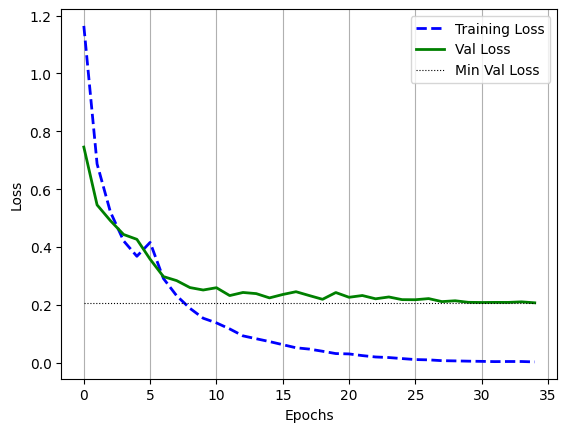

In [32]:
train_loss = h1["train_loss"] + h2["train_loss"]
val_loss = h1["val_loss"] + h2["val_loss"]
plot_neural(
    epochs= len(train_loss), train_loss= train_loss, val_loss = val_loss
)

In [33]:
from typing import Literal
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

def evaluate(y_true, y_pred):
    print(classification_report(y_true, y_pred, digits=4))
    return confusion_matrix(y_true, y_pred)

def format_cm(cm, *, 
              class_names: list[str] | None = None, 
              normalize: bool = False,
              normalize_axis: Literal[0, 1] = 1) -> pd.DataFrame:
    if not class_names:
        class_names = [f"class-{i}" for i in range(len(cm))]
    
    cm_df = pd.DataFrame(cm,
                         index=[f"True: {c}" for c in class_names],
                         columns=[f"Pred: {c}" for c in class_names]
                         )
    if not normalize:
        return cm_df
    
    cm_normalized = cm_df.div(cm_df.sum(axis=normalize_axis), axis= 0 if normalize_axis == 1 else 1)
    cm_normalized = cm_normalized.round(4)
    return cm_normalized

In [35]:
y_test_v = []
y_test_pred = []

net.eval()
with torch.no_grad():
    for step, batch in enumerate(test_loader, 1):
        _data = batch["data"]
        _label = batch["label"].to(GPU).reshape((-1))
        
        _data = _data.reshape((_data.shape[0], 3, 32, 32))
        _data = _data / 255.0
        _data = val_tf(_data)
        _data = _data.to(GPU)
        
        logit = net(_data)
        y_pred = logit.argmax(1)
        
        y_test_v.extend(_label.cpu().numpy())
        y_test_pred.extend(y_pred.cpu().numpy())

cm = evaluate(y_test_v, y_test_pred)
format_cm(cm, class_names=label_name, normalize=True)

              precision    recall  f1-score   support

           0     0.9413    0.9630    0.9521      1000
           1     0.9769    0.9740    0.9755      1000
           2     0.9404    0.9310    0.9357      1000
           3     0.8918    0.8650    0.8782      1000
           4     0.9407    0.9510    0.9458      1000
           5     0.8978    0.9050    0.9014      1000
           6     0.9528    0.9690    0.9608      1000
           7     0.9647    0.9560    0.9603      1000
           8     0.9765    0.9570    0.9667      1000
           9     0.9566    0.9690    0.9627      1000

    accuracy                         0.9440     10000
   macro avg     0.9439    0.9440    0.9439     10000
weighted avg     0.9439    0.9440    0.9439     10000



,Pred: airplane,Pred: automobile,Pred: bird,Pred: cat,Pred: deer,Pred: dog,Pred: frog,Pred: horse,Pred: ship,Pred: truck
True: airplane,0.963,0.000,0.009,0.002,0.003,0.000,0.001,0.002,0.014,0.006
True: automobile,0.003,0.974,0.000,0.001,0.000,0.000,0.000,0.000,0.001,0.021
True: bird,0.012,0.000,0.931,0.013,0.014,0.010,0.015,0.004,0.001,0.000
True: cat,0.007,0.000,0.016,0.865,0.020,0.066,0.015,0.004,0.003,0.004
True: deer,0.002,0.000,0.007,0.012,0.951,0.011,0.007,0.010,0.000,0.000
True: dog,0.001,0.000,0.008,0.055,0.010,0.905,0.008,0.012,0.000,0.001
True: frog,0.004,0.000,0.010,0.010,0.001,0.004,0.969,0.001,0.000,0.001
True: horse,0.006,0.001,0.005,0.008,0.010,0.012,0.001,0.956,0.000,0.001
True: ship,0.021,0.003,0.003,0.003,0.001,0.000,0.001,0.001,0.957,0.010
True: truck,0.004,0.019,0.001,0.001,0.001,0.000,0.000,0.001,0.004,0.969


In [39]:
test_df_shifted = test_df.with_columns(pl.Series("data",[shift_data(data_list) for data_list in test_df["data"].to_list()] )) 
test_shifted_dataset = CIFARData(test_df_shifted)
test_shifted_loader = DataLoader(test_shifted_dataset, 
                       batch_size=BATCH, num_workers=2)

In [40]:
y_test_v_shifted = []
y_test_pred_shifted = []

net.eval()
with torch.no_grad():
    for step, batch in enumerate(test_shifted_loader, 1):
        _data = batch["data"]
        _label = batch["label"].to(GPU).reshape((-1))
        
        _data = _data.reshape((_data.shape[0], 3, 32, 32))
        _data = _data / 255.0
        _data = val_tf(_data)
        _data = _data.to(GPU)
        
        logit = net(_data)
        y_pred = logit.argmax(1)
        
        y_test_v_shifted.extend(_label.cpu().numpy())
        y_test_pred_shifted.extend(y_pred.cpu().numpy())

cm_shifted = evaluate(y_test_v_shifted, y_test_pred_shifted)
format_cm(cm_shifted, class_names=label_name, normalize=True)

              precision    recall  f1-score   support

           0     0.9352    0.9530    0.9440      1000
           1     0.9697    0.9600    0.9648      1000
           2     0.9301    0.9320    0.9311      1000
           3     0.8919    0.8750    0.8834      1000
           4     0.9398    0.9520    0.9459      1000
           5     0.8877    0.9010    0.8943      1000
           6     0.9543    0.9610    0.9576      1000
           7     0.9680    0.9390    0.9533      1000
           8     0.9677    0.9600    0.9639      1000
           9     0.9565    0.9670    0.9617      1000

    accuracy                         0.9400     10000
   macro avg     0.9401    0.9400    0.9400     10000
weighted avg     0.9401    0.9400    0.9400     10000



,Pred: airplane,Pred: automobile,Pred: bird,Pred: cat,Pred: deer,Pred: dog,Pred: frog,Pred: horse,Pred: ship,Pred: truck
True: airplane,0.953,0.002,0.013,0.001,0.004,0.002,0.001,0.001,0.016,0.007
True: automobile,0.007,0.960,0.000,0.001,0.000,0.000,0.000,0.000,0.006,0.026
True: bird,0.010,0.000,0.932,0.013,0.011,0.011,0.017,0.003,0.003,0.000
True: cat,0.005,0.001,0.011,0.875,0.018,0.069,0.011,0.004,0.003,0.003
True: deer,0.002,0.000,0.009,0.012,0.952,0.007,0.008,0.010,0.000,0.000
True: dog,0.005,0.000,0.013,0.053,0.009,0.901,0.008,0.010,0.000,0.001
True: frog,0.004,0.001,0.016,0.013,0.001,0.002,0.961,0.001,0.000,0.001
True: horse,0.007,0.000,0.004,0.009,0.017,0.023,0.001,0.939,0.000,0.000
True: ship,0.022,0.004,0.004,0.003,0.000,0.000,0.000,0.001,0.960,0.006
True: truck,0.004,0.022,0.000,0.001,0.001,0.000,0.000,0.001,0.004,0.967


In [41]:
torch.save(net.state_dict(), "resnet_ft_v03.pth")